***Import the libraries***

In [207]:
# import the python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

***Bring the dataset***

In [208]:
# Bring the dataset
diabetic = pd.read_csv("diabetic_data.csv")
mapping = pd.read_csv("IDS_mapping.csv")

***Apply the ID mappings to decode categorical columns where appropriate (admission_type_id, discharge_disposition_id, admission_source_id).***

In [209]:
# find the null index where divide "IDS_mapping" dataset
nan_index = mapping[mapping["admission_type_id"].isnull()].index

# Divide into three dataframe based on the NaN index
admission_map_df = mapping.iloc[ :nan_index[0]]
discharge_map_df = mapping.iloc[nan_index[0]+1:nan_index[1]].reset_index(drop=True)
source_map_df = mapping.iloc[nan_index[1]+1: ].reset_index(drop=True)

In [210]:
# Change the column name properly and delete the row
discharge_map_df.columns = discharge_map_df.iloc[0]
discharge_map_df = discharge_map_df.drop(index = 0)

source_map_df.columns = source_map_df.iloc[0]
source_map_df = source_map_df.drop(index = 0)

# Change the datatype from 'str' into 'int'
admission_map_df['admission_type_id'] = admission_map_df['admission_type_id'].astype(int)
discharge_map_df['discharge_disposition_id'] = discharge_map_df['discharge_disposition_id'].astype(int)
source_map_df['admission_source_id'] = source_map_df['admission_source_id'].astype(int)

# Set each id as index
admission_map_df = admission_map_df.set_index("admission_type_id")
discharge_map_df = discharge_map_df.set_index("discharge_disposition_id")
source_map_df = source_map_df.set_index("admission_source_id")

In [211]:
# Change into dictionary
admission_dict = admission_map_df['description'].to_dict()
discharge_dict = discharge_map_df['description'].to_dict()
source_dict = source_map_df['description'].to_dict()
print(admission_dict)
print(discharge_dict)
print(source_dict)

# Change the datatype from 'float' into 'int'
diabetic['admission_type_id'] = diabetic['admission_type_id'].astype(int)
diabetic['discharge_disposition_id'] = diabetic['discharge_disposition_id'].astype(int)
diabetic['admission_source_id'] = diabetic['admission_source_id'].astype(int)

diabetic['admission_type_id'] = diabetic['admission_type_id'].map(admission_dict)
diabetic['discharge_disposition_id'] = diabetic['discharge_disposition_id'].map(admission_dict)
diabetic['admission_source_id'] = diabetic['admission_source_id'].map(admission_dict)

{1: 'Emergency', 2: 'Urgent', 3: 'Elective', 4: 'Newborn', 5: 'Not Available', 6: nan, 7: 'Trauma Center', 8: 'Not Mapped'}
{1: 'Discharged to home', 2: 'Discharged/transferred to another short term hospital', 3: 'Discharged/transferred to SNF', 4: 'Discharged/transferred to ICF', 5: 'Discharged/transferred to another type of inpatient care institution', 6: 'Discharged/transferred to home with home health service', 7: 'Left AMA', 8: 'Discharged/transferred to home under care of Home IV provider', 9: 'Admitted as an inpatient to this hospital', 10: 'Neonate discharged to another hospital for neonatal aftercare', 11: 'Expired', 12: 'Still patient or expected to return for outpatient services', 13: 'Hospice / home', 14: 'Hospice / medical facility', 15: 'Discharged/transferred within this institution to Medicare approved swing bed', 16: 'Discharged/transferred/referred another institution for outpatient services', 17: 'Discharged/transferred/referred to this institution for outpatient ser

***The Data Shape and Data Type to look over the dataset***

In [212]:
# Dataset shape, data types, and memory usage
print("Data Shape:", diabetic.shape)
print(diabetic.dtypes)
print("Memory Use:", diabetic.info(memory_usage='deep'))

Data Shape: (101766, 50)
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              ob

***Frequency distributions and value counts for all categorical features***

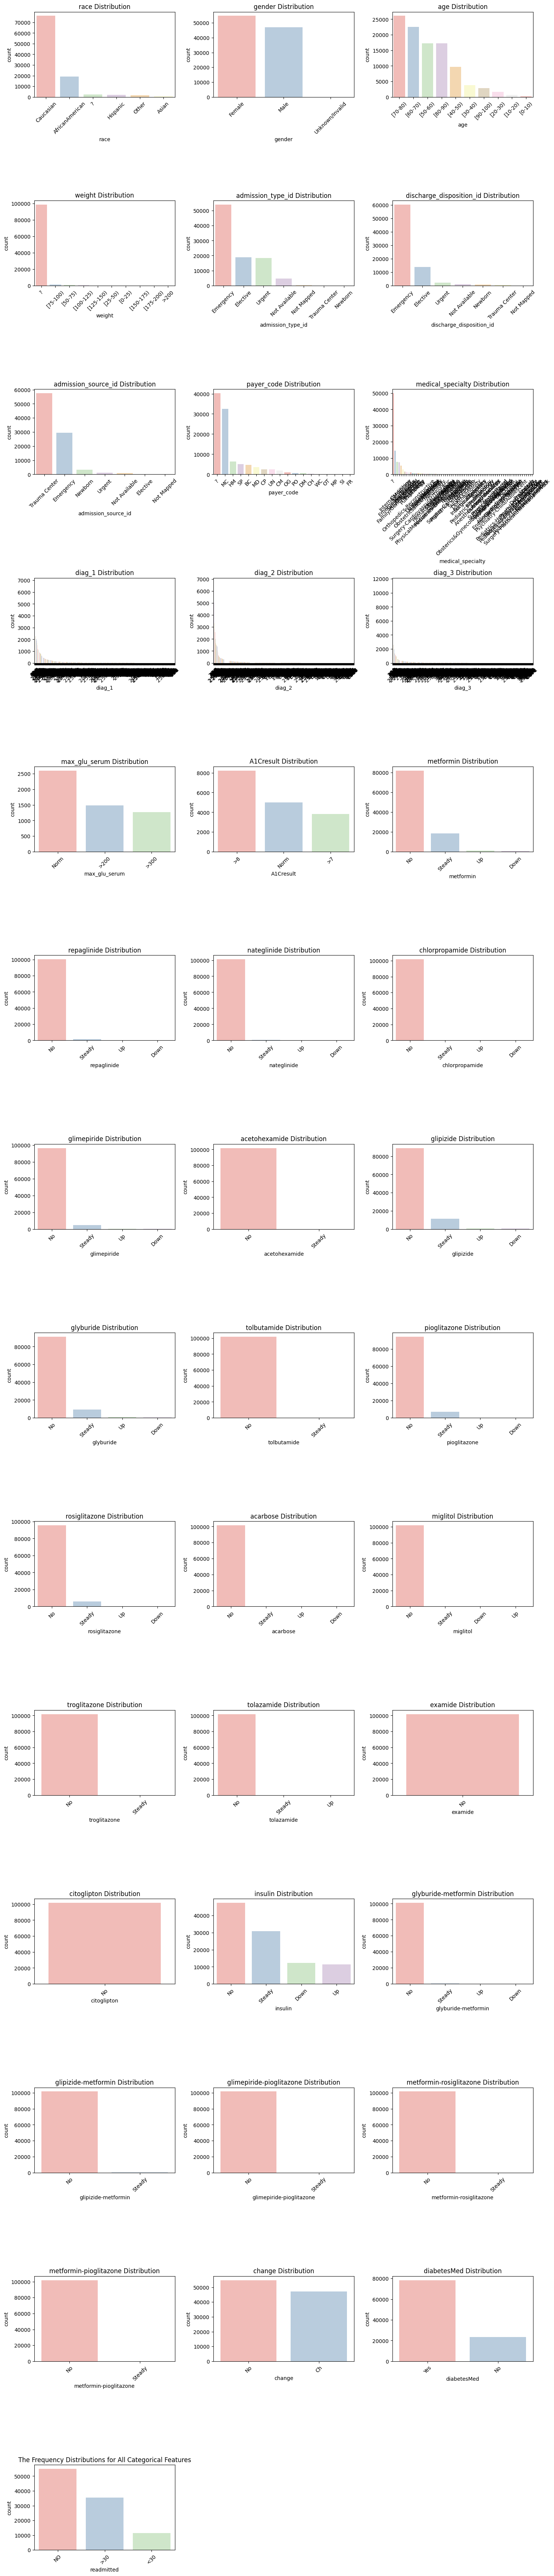

In [213]:
categorical_data = diabetic.select_dtypes(include=['object']).columns

n_cols = 3
n_rows = (len(categorical_data) + n_cols - 1)

plt.figure(figsize=(15, 5 * n_rows))
for i, col in enumerate(categorical_data, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(
        data=diabetic,
        x=col,
        order=diabetic[col].value_counts().index,
        palette='Pastel1'
    )
    
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
plt.title("The Frequency Distributions for All Categorical Features")
plt.tight_layout()
plt.show()

***Readmitted*** show imbalance.   
***metformin-piogitazone***, ***metformin-rosiglitazone***, ***glimepiride-pioglitazone***, ***glipizide-metformin***, glyburide-metformin***, ***citoglipton***, ***examide***, ***tolazamide***, ***troglitazone***, ***miglitol***, ****acarbose***, ***tolbutamide***, ***acetohexamide***, ***chlorpropamide*** show that most of the variables are "NO". It could occur the loss of model performance.   
***weight Distribution*** show (?, which is null) mostly.  

In [214]:
for _ in categorical_data:
    print(diabetic[_].value_counts())

race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64
weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64
admission_type_id
Emergency        53990
Elective         18869
Urgent           18480
Not Available     4785
Not Mapped         320
Trauma Center       21
Newborn             10
Name: count, dtype: int64
discharge_disposition_id
Emergency        60234
Elective         13954
Ur


***Missing Value Analysis and Handling the Missing values***

In [215]:
# Replace missing values "?" into Null
diabetic = diabetic.replace('?', np.nan)

# Check the columns having the Nulls
null_cols = diabetic.columns[diabetic.isna().sum() > 0]
diabetic[null_cols].isna().sum()

race                         2273
weight                      98569
admission_type_id            5291
discharge_disposition_id    22720
admission_source_id          9358
payer_code                  40256
medical_specialty           49949
diag_1                         21
diag_2                        358
diag_3                       1423
max_glu_serum               96420
A1Cresult                   84748
dtype: int64

The featurea having the Nulls are categorical.

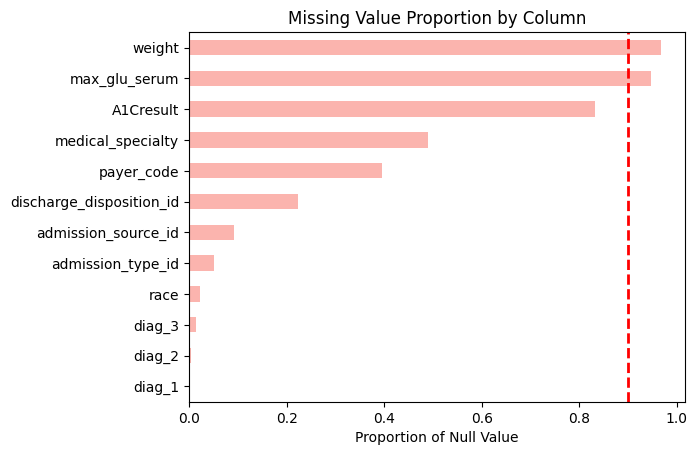

In [216]:
#The Nulls Ratio for each column
ratio = diabetic[null_cols].isnull().mean().sort_values(ascending=True)
ratio.plot(kind='barh', colormap ='Pastel1')
plt.axvline(x=0.9, color='red', linestyle='--', linewidth=2)
plt.xlabel('Proportion of Null Value')
plt.title('Missing Value Proportion by Column')
plt.show()

***weight*** and ***max_glu_serum*** are over 90% of null proportion.   
Need to handle the nulls for ***A1Cresult***,***medical_specialty***, ***race***.   
***payer_code*** means that a unique alphanumeric identifier assigned to insurance companies or health plans, it'll be deleted.   
***diag_3***, ***diag_2***, ***diag_3*** are about the diagnose code. the proportion is too small, and I couldn't assign the unknown because it's basically based on the dianose. So I'll delete the nulls.   
***discharge_disposition_id***, ***admission_source_id***, ***admission_type_id***s' nulls are replaced into "NULL" from the mapping dataset.

In [217]:
# Find the columns where the ration of null is over than 90%
columns_90 = diabetic.columns[diabetic.isnull().mean() > 0.90]
print(columns_90)

# Check the distribution between weight and readmitted
weight_matrix = pd.crosstab(diabetic['weight'],diabetic['readmitted'])
print(weight_matrix)
diabetic = diabetic.drop(columns = 'weight')

# Check it later after modeling
diabetic['max_glu_serum'] = diabetic['max_glu_serum'].fillna('UNKNOWN')
max_glu_matrix = pd.crosstab(diabetic['max_glu_serum'],diabetic['readmitted'])
print(max_glu_matrix)

Index(['weight', 'max_glu_serum'], dtype='object')
readmitted  <30  >30   NO
weight                   
>200          0    3    0
[0-25)        8   31    9
[100-125)    67  292  266
[125-150)    12   69   64
[150-175)     3   16   16
[175-200)     1    5    5
[25-50)       8   42   47
[50-75)     105  389  403
[75-100)    153  663  520
readmitted       <30    >30     NO
max_glu_serum                     
>200             185    530    770
>300             181    521    562
Norm             295    885   1417
UNKNOWN        10696  33609  52115


The weight from frequency distribution plot and here shows that it is not important variable. So I deleted the ***weight***.
However ***max_glu_serum*** from frequency distribution plot is somewhat meaningful, so it can be a little risky to delete it. So, I make replace (?) into "Unknown".

In [218]:
# Replace the race NAs into Unknown
diabetic['race'] = diabetic['race'].fillna('UNKNWON')
diabetic['medical_specialty'] = diabetic['medical_specialty'].fillna('UNKNOWN')
diabetic['A1Cresult'] = diabetic['A1Cresult'].fillna('None')

# Replace the admission_type_id, discharge_disposition_id, admission_source_id into 'NULL' which is originally indicated in mapping dataset
diabetic['admission_type_id'] = diabetic['admission_type_id'].fillna('NULL')
diabetic['discharge_disposition_id'] = diabetic['discharge_disposition_id'].fillna('NULL')
diabetic['admission_source_id'] = diabetic['admission_source_id'].fillna('NULL')

The nulls from ***race**, ***medical_specialty***, ***A1Cresult*** are replaced into UNKNOWN.   
***discharge_disposition_id***, ***admission_source_id***, ***admission_type_id***s' nulls are replaced into "NULL" from the mapping dataset.

In [219]:
# Drop the meaningless columns
diabetic = diabetic.drop(columns=['encounter_id', 'patient_nbr', 'payer_code'])

In [220]:
#Drop the rest of Null (which are the small portion of the dataset)
print(diabetic.shape)
diabetic = diabetic.dropna()
print(diabetic.shape)

(101766, 46)
(100244, 46)


The rest of the nulls are from ***diag_1***, ***diag_2***, ***diag_3***.   
Drop the null result in 1522 rows loss.

***Descriptive statistics for all numerical features (mean, median, std, quartiles, skewness, kurtosis)***

In [221]:
# Descriptive statistic for all numerical features
stat_table = diabetic.select_dtypes(include=['int64', 'float64']).describe().transpose()
stat_table['median'] = diabetic.select_dtypes(include=['int64', 'float64']).median()
stat_table['skew'] = diabetic.select_dtypes(include=['int64', 'float64']).skew()
stat_table['kurtosis'] = diabetic.select_dtypes(include=['int64', 'float64']).kurtosis()
stat_table

,count,mean,std,min,25%,50%,75%,max,median,skew,kurtosis
time_in_hospital,100244.0,4.420275,2.991273,1.0,2.0,4.0,6.0,14.0,4.0,1.124030,0.821465
num_lab_procedures,100244.0,43.173716,19.691484,1.0,32.0,44.0,57.0,132.0,44.0,-0.237563,-0.243034
num_procedures,100244.0,1.350275,1.710913,0.0,0.0,1.0,2.0,6.0,1.0,1.304885,0.820350
num_medications,100244.0,16.117823,8.116424,1.0,11.0,15.0,20.0,81.0,15.0,1.336562,3.502598
number_outpatient,100244.0,0.372561,1.274074,0.0,0.0,0.0,0.0,42.0,0.0,8.807166,146.825322
number_emergency,100244.0,0.199014,0.933541,0.0,0.0,0.0,0.0,76.0,0.0,22.901066,1193.037158
number_inpatient,100244.0,0.639470,1.262773,0.0,0.0,0.0,1.0,21.0,0.0,3.571237,20.150022
number_diagnoses,100244.0,7.497007,1.839537,3.0,6.0,8.0,9.0,16.0,8.0,-0.792975,-0.371053


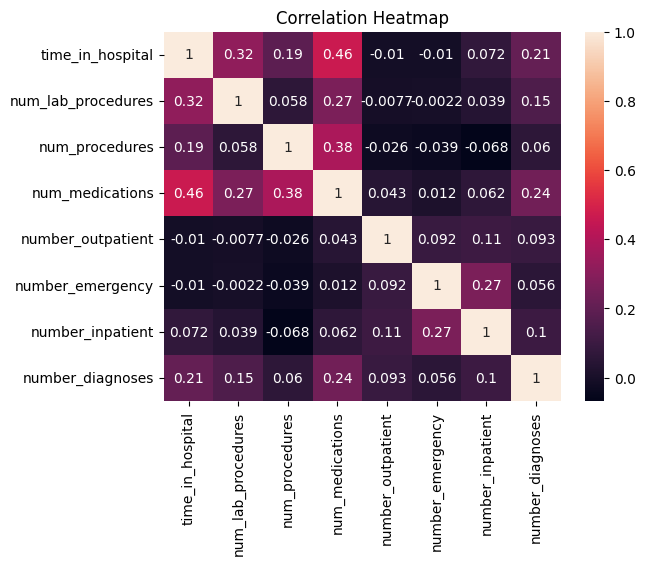

In [222]:
corr = diabetic.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

***number_medications*** and ***time_in_hospital*** show the correlationship with 0.46 with is moderate but highest correlation

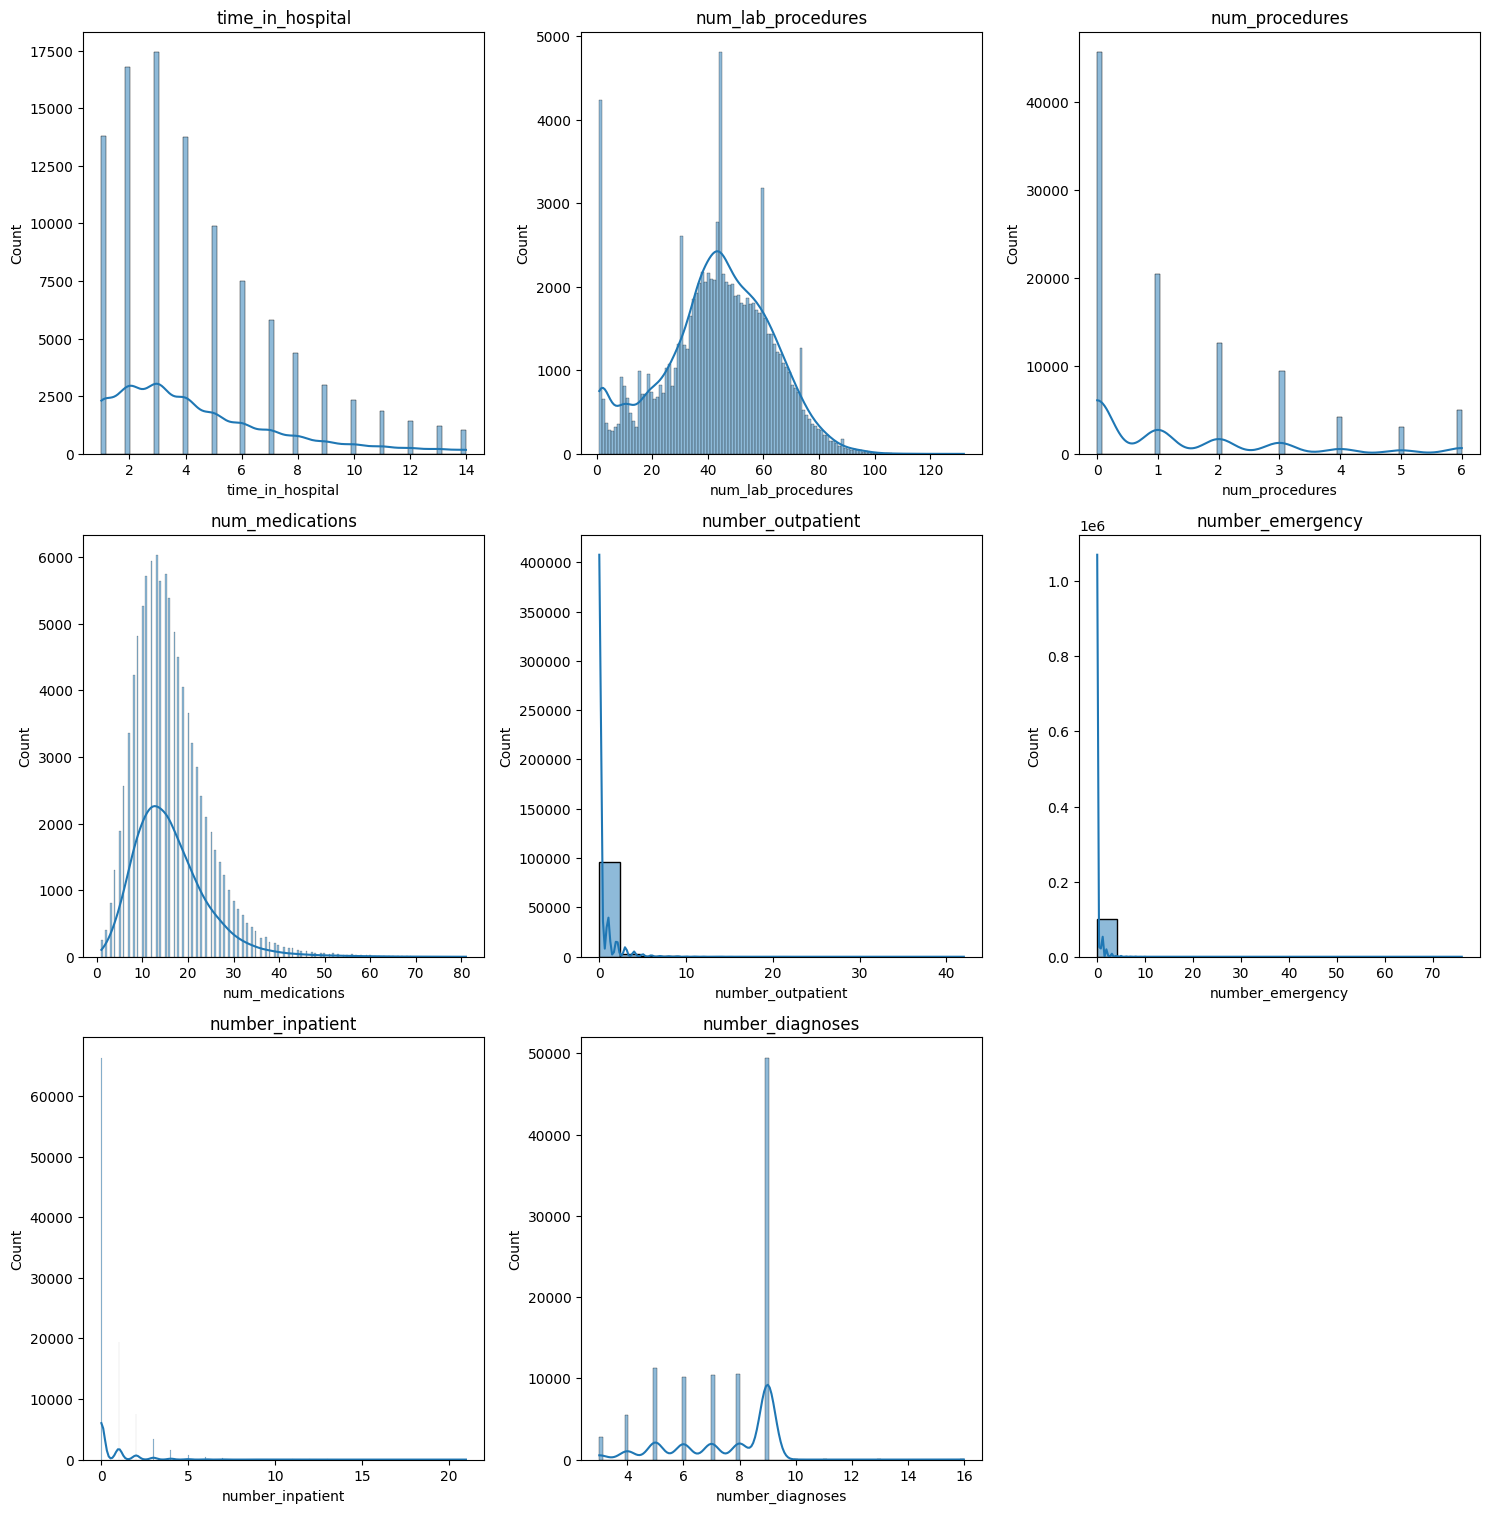

In [223]:
numeric_cols = diabetic.select_dtypes(include=['int64', 'float64']).columns


n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1)
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(diabetic[col], kde=True, kde_kws={'bw_adjust': 1.5} )
    plt.title(col)

plt.tight_layout()
plt.show()

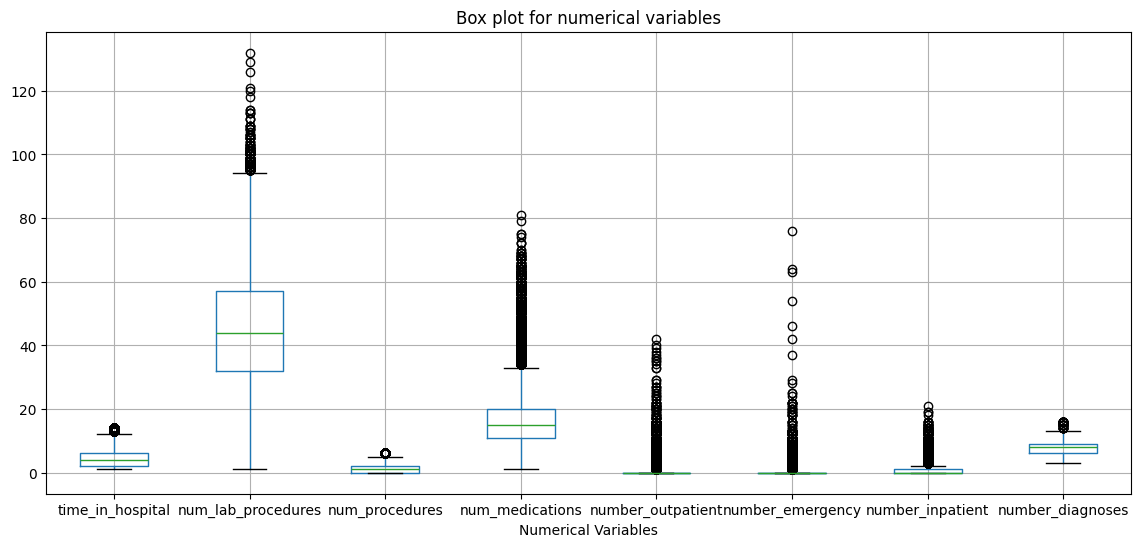

In [224]:
plt.figure(figsize=(14, 6))
diabetic[numeric_cols].boxplot()
plt.title("Box plot for numerical variables")
plt.xlabel("Numerical Variables")
plt.show()

***number_outpatient***,***number_emergency***, ***number_inpatient*** shows high skewness, high kurtosis, and its 75% quntile is 0~1. It means that they might have the outliers.   
Other features shows normally distributtion, indicating less problem about the outliers.

In [225]:
# def remove_outliers_iqr(df, columns=None):

#     if columns is None:
#         columns = df.select_dtypes(include=[np.number]).columns
#     df_clean = df.copy()
#     for col in columns:
#         Q1 = df_clean[col].quantile(0.25)
#         Q3 = df_clean[col].quantile(0.75)
#         IQR = Q3 - Q1
#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR
#         df_clean = df_clean[
#             (df_clean[col] >= lower_bound) & 
#             (df_clean[col] <= upper_bound)
#         ]
#     return df_clean
# print(diabetic.shape)
# diabetic = remove_outliers_iqr(diabetic)
# print(diabetic.shape)

from scipy.stats import zscore
def remove_outliers_z(df, columns=None):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    z_scores = df[numeric_cols].apply(zscore)
    threshold = 3
    df_no_outliers = df[(np.abs(z_scores) < threshold).all(axis=1)]
    return df_no_outliers
print(diabetic.shape)
diabetic = remove_outliers_z(diabetic)
print(diabetic.shape)

(100244, 46)
(93311, 46)


When applying Z-score to remove outliers: (100244, 39) - > (93311, 39)
When applying IQR to remove outliers: (100244, 39) -> (65517, 39)
So, I decided to remove by using the z-score

***Duplicate - There's no duplicates in this dataset*** 

In [226]:
print("The number of duplicates:", diabetic.duplicated().sum())


The number of duplicates: 0


***Drop the Columns***

In [227]:
cols = diabetic.columns
print(cols)
for _ in cols:
    print(diabetic[_].value_counts())

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'medical_specialty', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')
race
Caucasian          69875
AfricanAmerican    17500
UNKNWON             2099
Hispanic            1844
Other               1391
A

In [228]:
# Drop the Columns which are all the values are 'No' except for 1-3 steady
diabetic = diabetic.drop(columns=['acetohexamide',
                                  'troglitazone',
                                  'examide',
                                  'citoglipton',
                                  'glimepiride-pioglitazone',
                                  'metformin-rosiglitazone',
                                  'metformin-pioglitazone'])

In [229]:
# Frequence distributions and value counts for all categorical features
numeric_cols = diabetic.select_dtypes(include=['object']).columns
print(numeric_cols)
cols_category = ['race',
                 'gender',
                 'age',
                 'admission_type_id',
                 'discharge_disposition_id',
                 'admission_source_id']

for _ in cols_category:
    print(diabetic[_].value_counts())

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'medical_specialty',
       'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 'insulin',
       'glyburide-metformin', 'glipizide-metformin', 'change', 'diabetesMed',
       'readmitted'],
      dtype='object')
race
Caucasian          69875
AfricanAmerican    17500
UNKNWON             2099
Hispanic            1844
Other               1391
Asian                602
Name: count, dtype: int64
gender
Female             50183
Male               43125
Unknown/Invalid        3
Name: count, dtype: int64
age
[70-80)     24330
[60-70)     20748
[80-90)     16204
[50-60)     15722
[40-50)      8608
[30-40)      3262
[90-100)     2668
[20-30)      1266
[10-20)       438
[0-1

In [231]:
cols_category2 = ['medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'A1Cresult', 'metformin', 'repaglinide',
                  'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide',
                  'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
                  'miglitol', 'tolazamide', 'insulin', 'glyburide-metformin',
                  'glipizide-metformin', 'change', 'diabetesMed', 'readmitted'] 

for _ in cols_category2:
    print(diabetic[_].value_counts())

#diabetic = diabetic.drop(columns = ['diag_1', 'diag_2', 'diag_3'])

medical_specialty
UNKNOWN                   45802
InternalMedicine          13572
Emergency/Trauma           6974
Family/GeneralPractice     6881
Cardiology                 4986
                          ...  
Proctology                    1
Speech                        1
SportsMedicine                1
Perinatology                  1
Neurophysiology               1
Name: count, Length: 73, dtype: int64
diag_1
428    6368
414    5791
786    3838
486    3311
410    3256
       ... 
52        1
391       1
690       1
10        1
V51       1
Name: count, Length: 711, dtype: int64
diag_2
276     6145
428     6131
250     5431
427     4711
401     3611
        ... 
E968       1
140        1
E882       1
703        1
893        1
Name: count, Length: 739, dtype: int64
diag_3
250     11093
401      7968
276      4764
428      4192
427      3636
        ...  
236         1
837         1
E987        1
V07         1
971         1
Name: count, Length: 786, dtype: int64
A1Cresult
None    77865
>

***EDA: Exploratory Data Analysis***

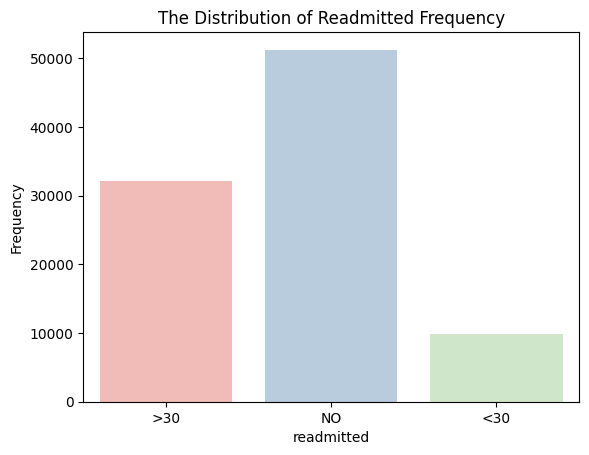

In [232]:
sns.countplot(x='readmitted', data=diabetic, palette='Pastel1')
plt.title("The Distribution of Readmitted Frequency")
plt.ylabel("Frequency")
plt.show()

The frequency of ***No*** is 5 times of the frequency of ***<30***.   
So, it should be handeled the imbalance of target variable for the model performance.
I'll apply sample_weight='balance_weight' this command on the ***TabularPredictor*** model.

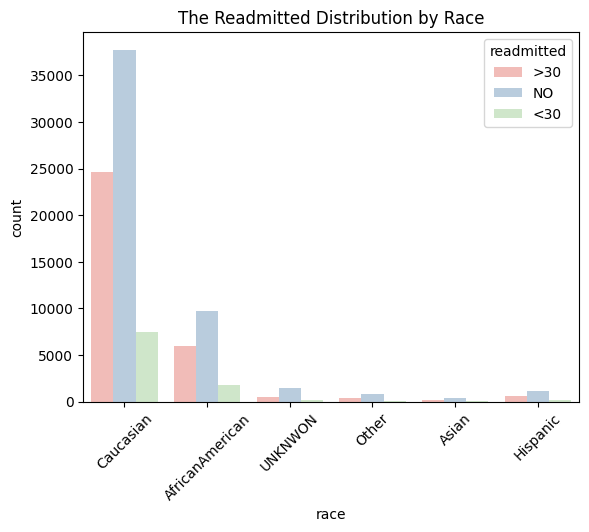

In [233]:
sns.countplot(data=diabetic, x='race', hue='readmitted', palette='Pastel1')
plt.title('The Readmitted Distribution by Race')
plt.xticks(rotation=45)
plt.show()

Caucasian has the highest number of diabetic patients, and then African/American has the second highest number of diabetic patients, but the gap between Caucasian and AfricanAmerican is pretty huge.

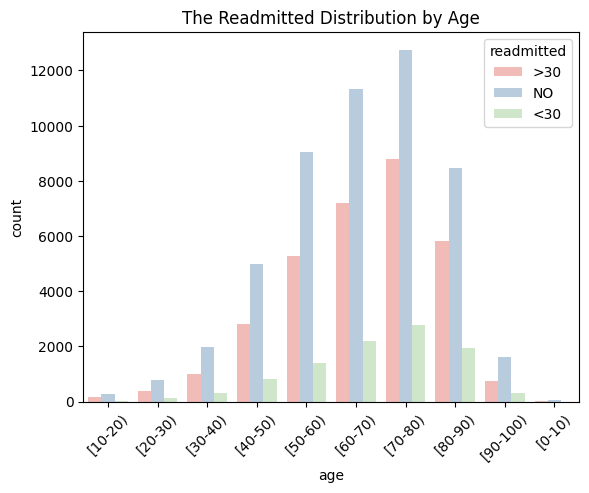

In [234]:
sns.countplot(data=diabetic, x='age', hue='readmitted', palette='Pastel1')
plt.title('The Readmitted Distribution by Age')
plt.xticks(rotation=45)
plt.show()

The age between 50 and 90 show the high density of the number of patients.   
Especially between 70 and 80 show the highest for all the ***readmitted*** categories.

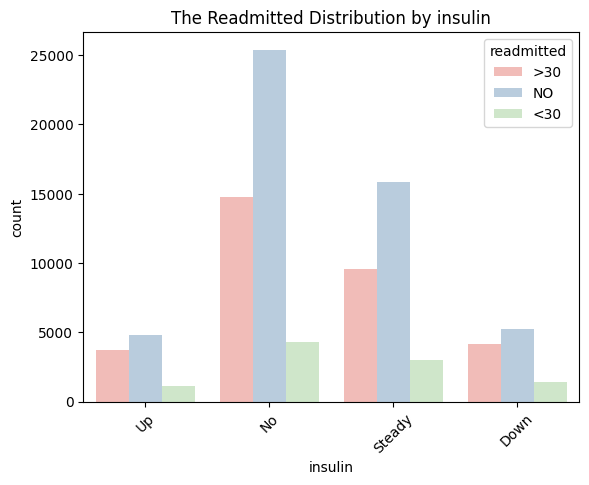

In [235]:
sns.countplot(data=diabetic, x='insulin', hue='readmitted', palette='Pastel1')
plt.title('The Readmitted Distribution by insulin')
plt.xticks(rotation=45)
plt.show()

Changes in insulin are associated with a higher proportion risk of readmission, while patients with No and Steady insulin tend to have lower readmission rates.

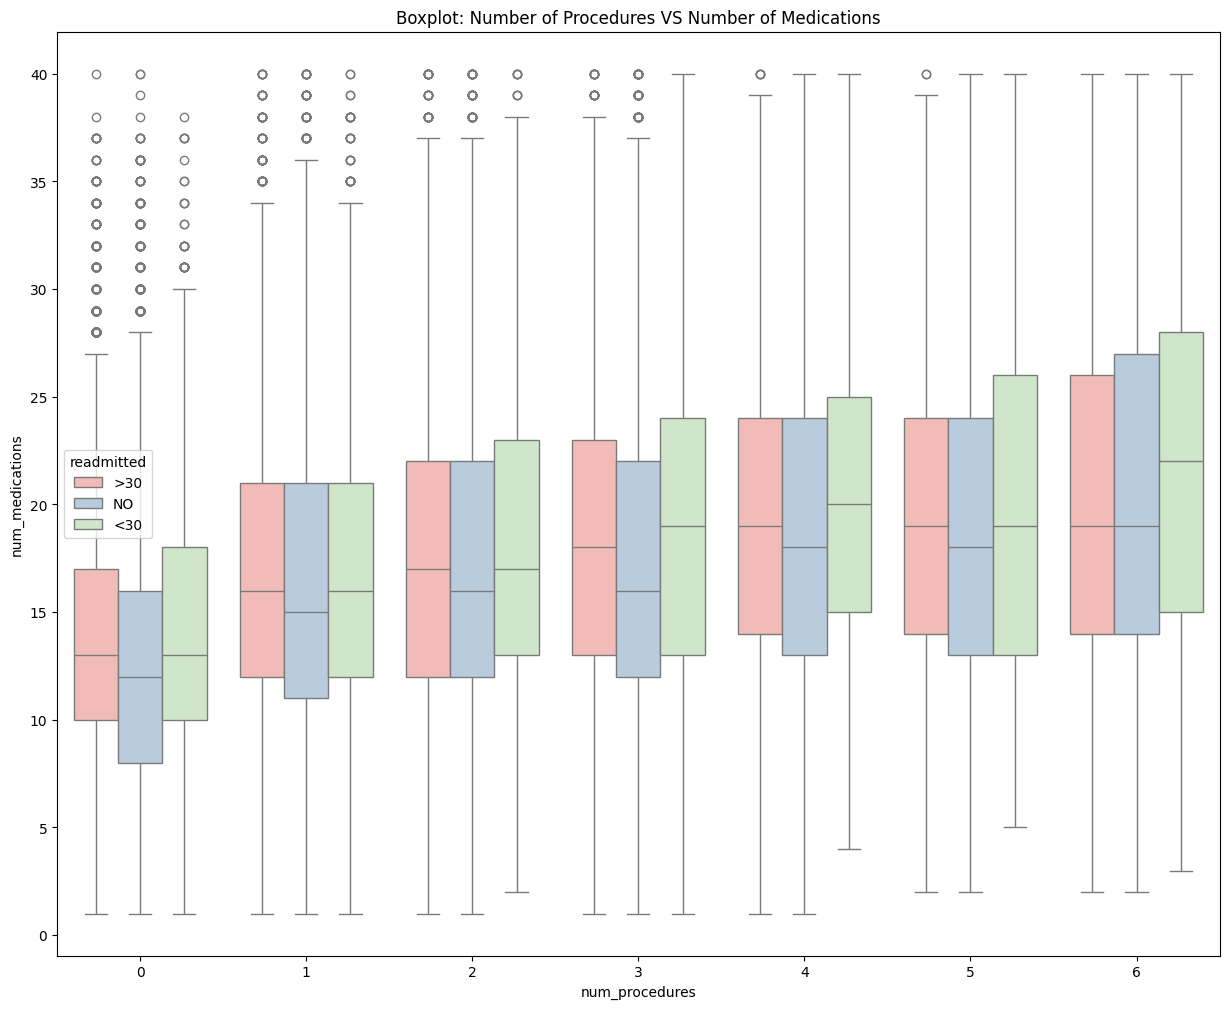

In [236]:
plt.figure(figsize=(15, 12))
sns.boxplot(
    data=diabetic,
    x='num_procedures',
    y='num_medications',
    hue='readmitted',
    palette='Pastel1'
)
plt.title('Boxplot: Number of Procedures VS Number of Medications')
plt.show()

The number of medications increases consistently with the number of procedures, indicating a strong positive relationship between treatment intensity and medication usage.
Patients who were readmitted within 30 days (<30) tend to receive a higher number of medications across all procedure levels.

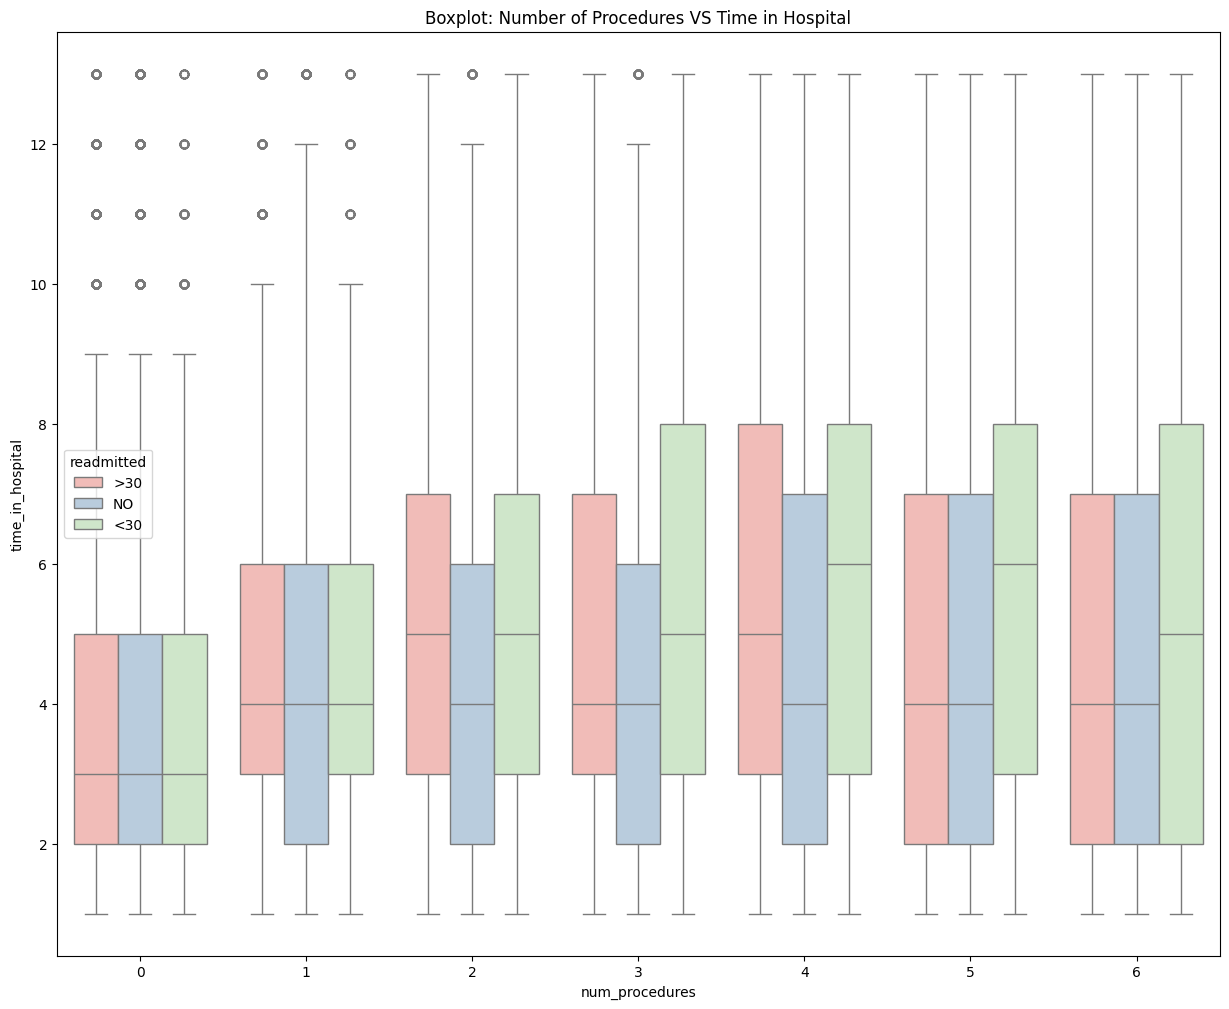

In [237]:
plt.figure(figsize=(15, 12))
sns.boxplot(
    data=diabetic,
    x='num_procedures',
    y='time_in_hospital',
    hue='readmitted',
    palette='Pastel1'
)
plt.title('Boxplot: Number of Procedures VS Time in Hospital')
plt.show()


Patients who were readmitted within 30 days (<30) tend to receive a higher time in hospitals after 2 procedure levels.

***Feature Importance Preliminary Assessment***

In [238]:
# To test the Chi-squred test between categorical data and readmitted to find the relationship.
from scipy.stats import chi2_contingency

# This function result the p-value and feature which is statistically significant with readmitted.
def chi_suqred(col1):
  contingency_table = pd.crosstab(diabetic[col1],diabetic['readmitted'])
  chi2, p, dof, expected = chi2_contingency(contingency_table)
  if p < 0.05:
    print("p-value for", col1, ":", p)

diabetic.select_dtypes(include=['object']).columns
for _ in diabetic.select_dtypes(include=['object']).columns:
  chi_suqred(_)

p-value for race : 4.418856354765428e-45
p-value for gender : 1.4116538023657463e-05
p-value for age : 5.311257520026287e-62
p-value for admission_type_id : 2.1017758717943685e-65
p-value for discharge_disposition_id : 6.373329327849905e-136
p-value for admission_source_id : 2.399265324120497e-119
p-value for medical_specialty : 6.165146294448896e-136
p-value for diag_1 : 2.0574325850514243e-284
p-value for diag_2 : 1.545531035054073e-169
p-value for diag_3 : 2.3772309528137175e-134
p-value for max_glu_serum : 7.583433361607071e-07
p-value for A1Cresult : 1.400960336683923e-09
p-value for metformin : 1.2435452993462052e-13
p-value for repaglinide : 1.3426762439552297e-10
p-value for chlorpropamide : 0.04836288687142997
p-value for glimepiride : 0.007535267007504199
p-value for glipizide : 1.5401319376638185e-10
p-value for pioglitazone : 6.909374671297647e-05
p-value for rosiglitazone : 3.7482846665411815e-07
p-value for acarbose : 6.159593194765561e-05
p-value for insulin : 2.20855877

***4) Modeling***

***DATASET SPLIT***

In [239]:
# Divide into train data and unseen dataset
from sklearn.model_selection import train_test_split

X = diabetic.drop(columns=['readmitted'])
y = diabetic['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.05,
    random_state=42,
    stratify=y
)
train_df = X_train.copy()
train_df['readmitted'] = y_train

test_df = X_test.copy()
test_df['readmitted'] = y_test

In [240]:
# Save the unseen_dataset
test_df.to_csv('unseen_data.csv', index=False)

In [241]:
# Divide into train data and test dataset
from sklearn.model_selection import train_test_split

X = train_df.drop(columns=['readmitted'])
y = train_df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
train_df = X_train.copy()
train_df['readmitted'] = y_train

test_df = X_test.copy()
test_df['readmitted'] = y_test

In [242]:
print(train_df.shape)
print(test_df.shape)

(70916, 39)
(17729, 39)


In [246]:
from autogluon.tabular import TabularPredictor

predictor = TabularPredictor(
    label='readmitted',
    eval_metric='acc', # or 'f1_macro', 'roc_auc_ovo_macro'
    problem_type='multiclass',
    sample_weight='balance_weight',
    path='ag_models/'
).fit(
    train_data=train_df,
    presets='best_quality',  # or 'medium_quality' for faster training
    time_limit = 3600          # seconds; adjust as needed
)

leaderboard = predictor.leaderboard(test_df, silent=False)
leaderboard.to_csv('leaderboard.csv', index=False)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22631
CPU Count:          16
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       3.75 GB / 15.69 GB (23.9%)
Disk Space Avail:   154.11 GB / 476.17 GB (32.4%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluo

                      model  score_test  score_val eval_metric  pred_time_test  pred_time_val     fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0       WeightedEnsemble_L3    0.592983   0.587033    accuracy       37.414884      58.542282  2211.982086                 0.054642                0.010016           4.412666            3       True         17
1   RandomForestEntr_BAG_L2    0.592814   0.582041    accuracy       26.531447      47.026392  1629.461460                 1.792648                6.686374          72.836058            2       True         15
2    NeuralNetFastAI_BAG_L2    0.591799   0.582986    accuracy       32.676681      44.921176  2054.916593                 7.937881                4.581159         498.291191            2       True         11
3   RandomForestGini_BAG_L2    0.590050   0.580758    accuracy       27.035374      46.270780  1604.473603                 2.296574                5.930763     

In [247]:
leaderboard = predictor.leaderboard(test_df, silent=False)
leaderboard.to_csv('leaderboard.csv', index=False)

                      model  score_test  score_val eval_metric  pred_time_test  pred_time_val     fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0       WeightedEnsemble_L3    0.592983   0.587033    accuracy       18.815948      58.542282  2211.982086                 0.011125                0.010016           4.412666            3       True         17
1   RandomForestEntr_BAG_L2    0.592814   0.582041    accuracy       14.099192      47.026392  1629.461460                 0.933670                6.686374          72.836058            2       True         15
2    NeuralNetFastAI_BAG_L2    0.591799   0.582986    accuracy       16.963860      44.921176  2054.916593                 3.798338                4.581159         498.291191            2       True         11
3   RandomForestGini_BAG_L2    0.590050   0.580758    accuracy       13.965541      46.270780  1604.473603                 0.800019                5.930763     

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

predictor = TabularPredictor.load("ag_models/")
predictions = predictor.predict(test_df)

accuracy = accuracy_score(test_df['readmitted'], predictions)
f1_score = f1_score(test_df['readmitted'], predictions, average='macro')
report = classification_report(test_df['readmitted'], predictions)
confusion_mat = confusion_matrix(test_df['readmitted'], predictions)

print("accuracy:", accuracy)
print("f1 score:", f1_score)
print("classification report")
print(report)
print("confusion matrix")
print(confusion_mat)

accuracy: 0.5929832477861131
f1 score: 0.3878781217904787
              precision    recall  f1-score   support

         <30       0.50      0.01      0.02      1874
         >30       0.51      0.38      0.43      6118
          NO       0.62      0.84      0.71      9737

    accuracy                           0.59     17729
   macro avg       0.54      0.41      0.39     17729
weighted avg       0.57      0.59      0.54     17729

[[  15  665 1194]
 [   7 2297 3814]
 [   8 1528 8201]]


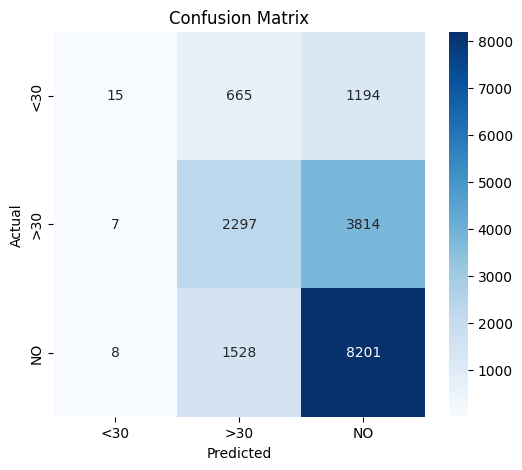

In [254]:
labels = sorted(test_df['readmitted'].unique())
confusion_mat = confusion_matrix(test_df['readmitted'], predictions, labels = labels)
plt.figure(figsize=(6,5))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [251]:
from autogluon.tabular import TabularPredictor
import pandas as pd

predictor = TabularPredictor.load("ag_models/")

unseen_data = pd.read_csv("unseen_data.csv")
predictions = predictor.predict(unseen_data)

predictions

0        NO
1        NO
2       >30
3        NO
4       >30
       ... 
4661    >30
4662     NO
4663     NO
4664    >30
4665    >30
Name: readmitted, Length: 4666, dtype: object